# Cache Data Investigation: NavSim vs Bench2Drive

This notebook investigates the cached data to understand how preprocessing affects the values
and to identify where the significant differences between NavSim and Bench2Drive are introduced.

## Key Issues to Investigate (from BENCH2DRIVE_CACHE_INVESTIGATION.md):
1. **Status Feature**: Why does Bench2Drive have -26.97 as minimum value?
2. **Heading**: Why is the range exactly ±0.110? Is this clipping or different units?
3. **Coordinates**: Why are X values centered at zero in Bench2Drive vs forward-biased in NavSim?
4. **Agent States**: Why are all agent values zero in Bench2Drive?

## 1. Setup and Imports

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pickle
import gzip
import torch
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Add project root to path
sys.path.append(str(Path.cwd().parent))

# Set style for better plots
plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"

# Cache paths
NAVSIM_CACHE = Path("/workspace/navsim_workspace/cache/training_cache")
B2D_CACHE = Path("/workspace/navsim_workspace/cache/bench2drive_Base_cache")

print(f"NavSim cache: {NAVSIM_CACHE}")
print(f"Bench2Drive cache: {B2D_CACHE}")
print(f"NavSim cache exists: {NAVSIM_CACHE.exists()}")
print(f"Bench2Drive cache exists: {B2D_CACHE.exists()}")

NavSim cache: /workspace/navsim_workspace/cache/training_cache
Bench2Drive cache: /workspace/navsim_workspace/cache/bench2drive_Base_cache
NavSim cache exists: True
Bench2Drive cache exists: True


## 2. Load Cache Statistics Function

In [ ]:
import gzip


def analyze_cache_statistics(cache_path, dataset_name, max_samples=10000):
    """Analyze statistics from cached data."""

    # Find all feature and target files - they are in .gz format
    feature_files = sorted(cache_path.glob("**/transfuser_feature.gz"))[:max_samples]
    target_files = sorted(cache_path.glob("**/transfuser_target.gz"))[:max_samples]

    print(f"\nAnalyzing {dataset_name} cache...")
    print(f"Found {len(feature_files)} feature files")

    if len(feature_files) == 0:
        print(f"WARNING: No cache files found in {cache_path}")
        return {}

    # Initialize statistics collectors
    stats = {
        "status": [],
        "trajectory_x": [],
        "trajectory_y": [],
        "trajectory_heading": [],
        "agent_states": [],
        "agent_labels": [],
        "camera_stats": [],
        "lidar_stats": [],
        "bev_classes": [],
    }

    # Process samples
    for feat_file, tgt_file in tqdm(
        zip(feature_files, target_files),
        total=len(feature_files),
        desc=f"Processing {dataset_name}",
    ):
        try:
            # Load gzipped data
            with gzip.open(feat_file, "rb") as f:
                features = pickle.load(f)
            with gzip.open(tgt_file, "rb") as f:
                targets = pickle.load(f)

            # Extract status features - different key names
            if "status_feature" in features:
                status = features["status_feature"].cpu().numpy()
                stats["status"].append(status)
            elif "status" in features:
                status = features["status"].cpu().numpy()
                stats["status"].append(status)

            # Extract trajectory from targets
            if "trajectory" in targets:
                traj = targets["trajectory"].cpu().numpy()
                # Ensure we have the right shape
                if len(traj.shape) == 2 and traj.shape[1] >= 3:
                    stats["trajectory_x"].extend(traj[:, 0])
                    stats["trajectory_y"].extend(traj[:, 1])
                    stats["trajectory_heading"].extend(traj[:, 2])

            # Extract agent information
            if "agent_state" in targets:
                agent_state = targets["agent_state"].cpu().numpy()
                agent_label = (
                    targets.get("agent_label", torch.zeros(agent_state.shape[0])).cpu().numpy()
                )

                # Get valid agents (label > 0)
                valid_mask = agent_label > 0
                if valid_mask.any():
                    stats["agent_states"].append(agent_state[valid_mask])
                    stats["agent_labels"].append(np.sum(valid_mask))
                else:
                    stats["agent_labels"].append(0)

            # Camera feature statistics
            if "camera_feature" in features:
                cam_feat = features["camera_feature"].cpu().numpy()
                stats["camera_stats"].append(
                    {
                        "shape": cam_feat.shape,
                        "min": cam_feat.min(),
                        "max": cam_feat.max(),
                        "mean": cam_feat.mean(),
                    }
                )

            # LiDAR feature statistics
            if "lidar_feature" in features:
                lidar_feat = features["lidar_feature"].cpu().numpy()
                stats["lidar_stats"].append(
                    {
                        "shape": lidar_feat.shape,
                        "nonzero": np.count_nonzero(lidar_feat),
                        "max": lidar_feat.max(),
                    }
                )

            # BEV semantic classes
            if "bev_semantic" in targets:
                bev = targets["bev_semantic"].cpu().numpy()
                unique_classes = np.unique(bev)
                stats["bev_classes"].append(unique_classes)

        except Exception as e:
            if len(feature_files) < 10:  # Only print errors for small datasets
                print(f"Error processing {feat_file}: {e}")
            continue

    # Print sample keys if we have data
    if len(feature_files) > 0:
        try:
            with gzip.open(feature_files[0], "rb") as f:
                sample_features = pickle.load(f)
            with gzip.open(target_files[0], "rb") as f:
                sample_targets = pickle.load(f)
            print(f"\nSample feature keys: {list(sample_features.keys())}")
            print(f"Sample target keys: {list(sample_targets.keys())}")
        except:
            pass

    return stats

## 3. Analyze Both Caches

In [3]:
# Analyze NavSim cache
nav_stats = analyze_cache_statistics(NAVSIM_CACHE, "NavSim", max_samples=2000)

# Analyze Bench2Drive cache
b2d_stats = analyze_cache_statistics(B2D_CACHE, "Bench2Drive", max_samples=2000)


Analyzing NavSim cache...
Found 2000 feature files


Processing NavSim: 100%|██████████| 2000/2000 [00:41<00:00, 48.49it/s]



Sample feature keys: ['camera_feature', 'lidar_feature', 'status_feature']
Sample target keys: ['trajectory', 'agent_states', 'agent_labels', 'bev_semantic_map']

Analyzing Bench2Drive cache...
Found 2000 feature files


Processing Bench2Drive: 100%|██████████| 2000/2000 [00:32<00:00, 61.03it/s]


Sample feature keys: ['camera_feature', 'lidar_feature', 'status_feature']
Sample target keys: ['trajectory', 'agent_states', 'agent_labels', 'bev_semantic_map']


## 4. Status Feature Analysis (Key Issue #1)

In [4]:
# Analyze status features in detail
print("=== STATUS FEATURE ANALYSIS ===")

# Convert to arrays
nav_status = np.array(nav_stats["status"]) if nav_stats["status"] else np.array([])
b2d_status = np.array(b2d_stats["status"]) if b2d_stats["status"] else np.array([])

if len(nav_status) > 0 and len(b2d_status) > 0:
    print(f"\nNavSim status shape: {nav_status.shape}")
    print(f"Bench2Drive status shape: {b2d_status.shape}")

    # Compute statistics for each dimension
    print("\nPer-dimension statistics:")
    print("Dim | NavSim [min, max, mean, std] | B2D [min, max, mean, std]")
    print("-" * 80)

    for i in range(min(nav_status.shape[1], b2d_status.shape[1])):
        nav_min, nav_max = nav_status[:, i].min(), nav_status[:, i].max()
        nav_mean, nav_std = nav_status[:, i].mean(), nav_status[:, i].std()

        b2d_min, b2d_max = b2d_status[:, i].min(), b2d_status[:, i].max()
        b2d_mean, b2d_std = b2d_status[:, i].mean(), b2d_status[:, i].std()

        print(
            f"{i:3d} | [{nav_min:7.2f}, {nav_max:7.2f}, {nav_mean:7.2f}, {nav_std:7.2f}] | "
            f"[{b2d_min:7.2f}, {b2d_max:7.2f}, {b2d_mean:7.2f}, {b2d_std:7.2f}]"
        )

    # Find extreme values in Bench2Drive
    print("\n=== EXTREME VALUE INVESTIGATION ===")
    extreme_threshold = 20
    extreme_mask = np.any(np.abs(b2d_status) > extreme_threshold, axis=1)
    extreme_indices = np.where(extreme_mask)[0]

    print(f"\nFound {len(extreme_indices)} samples with values > {extreme_threshold}")
    if len(extreme_indices) > 0:
        print("\nSample extreme values:")
        for idx in extreme_indices[:5]:
            print(f"  Sample {idx}: {b2d_status[idx]}")
            # Find which dimension has the extreme value
            extreme_dims = np.where(np.abs(b2d_status[idx]) > extreme_threshold)[0]
            print(f"    Extreme in dimensions: {extreme_dims}")

=== STATUS FEATURE ANALYSIS ===

NavSim status shape: (2000, 8)
Bench2Drive status shape: (2000, 8)

Per-dimension statistics:
Dim | NavSim [min, max, mean, std] | B2D [min, max, mean, std]
--------------------------------------------------------------------------------
  0 | [   0.00,    1.00,    0.27,    0.44] | [   0.00,    0.00,    0.00,    0.00]
  1 | [   0.00,    1.00,    0.65,    0.48] | [   1.00,    1.00,    1.00,    0.00]
  2 | [   0.00,    1.00,    0.09,    0.28] | [   0.00,    0.00,    0.00,    0.00]
  3 | [   0.00,    0.00,    0.00,    0.00] | [   0.00,    0.00,    0.00,    0.00]
  4 | [  -0.01,   15.23,    4.89,    3.41] | [  -0.08,   11.71,    2.74,    3.68]
  5 | [  -0.32,    0.03,   -0.10,    0.07] | [  -0.01,    1.15,    0.15,    0.26]
  6 | [  -2.72,    2.15,   -0.15,    0.79] | [ -26.55,   12.35,   -0.34,    3.20]
  7 | [  -1.93,    3.49,    0.13,    0.51] | [  -7.45,    8.48,    0.03,    0.81]

=== EXTREME VALUE INVESTIGATION ===

Found 17 samples with values > 20



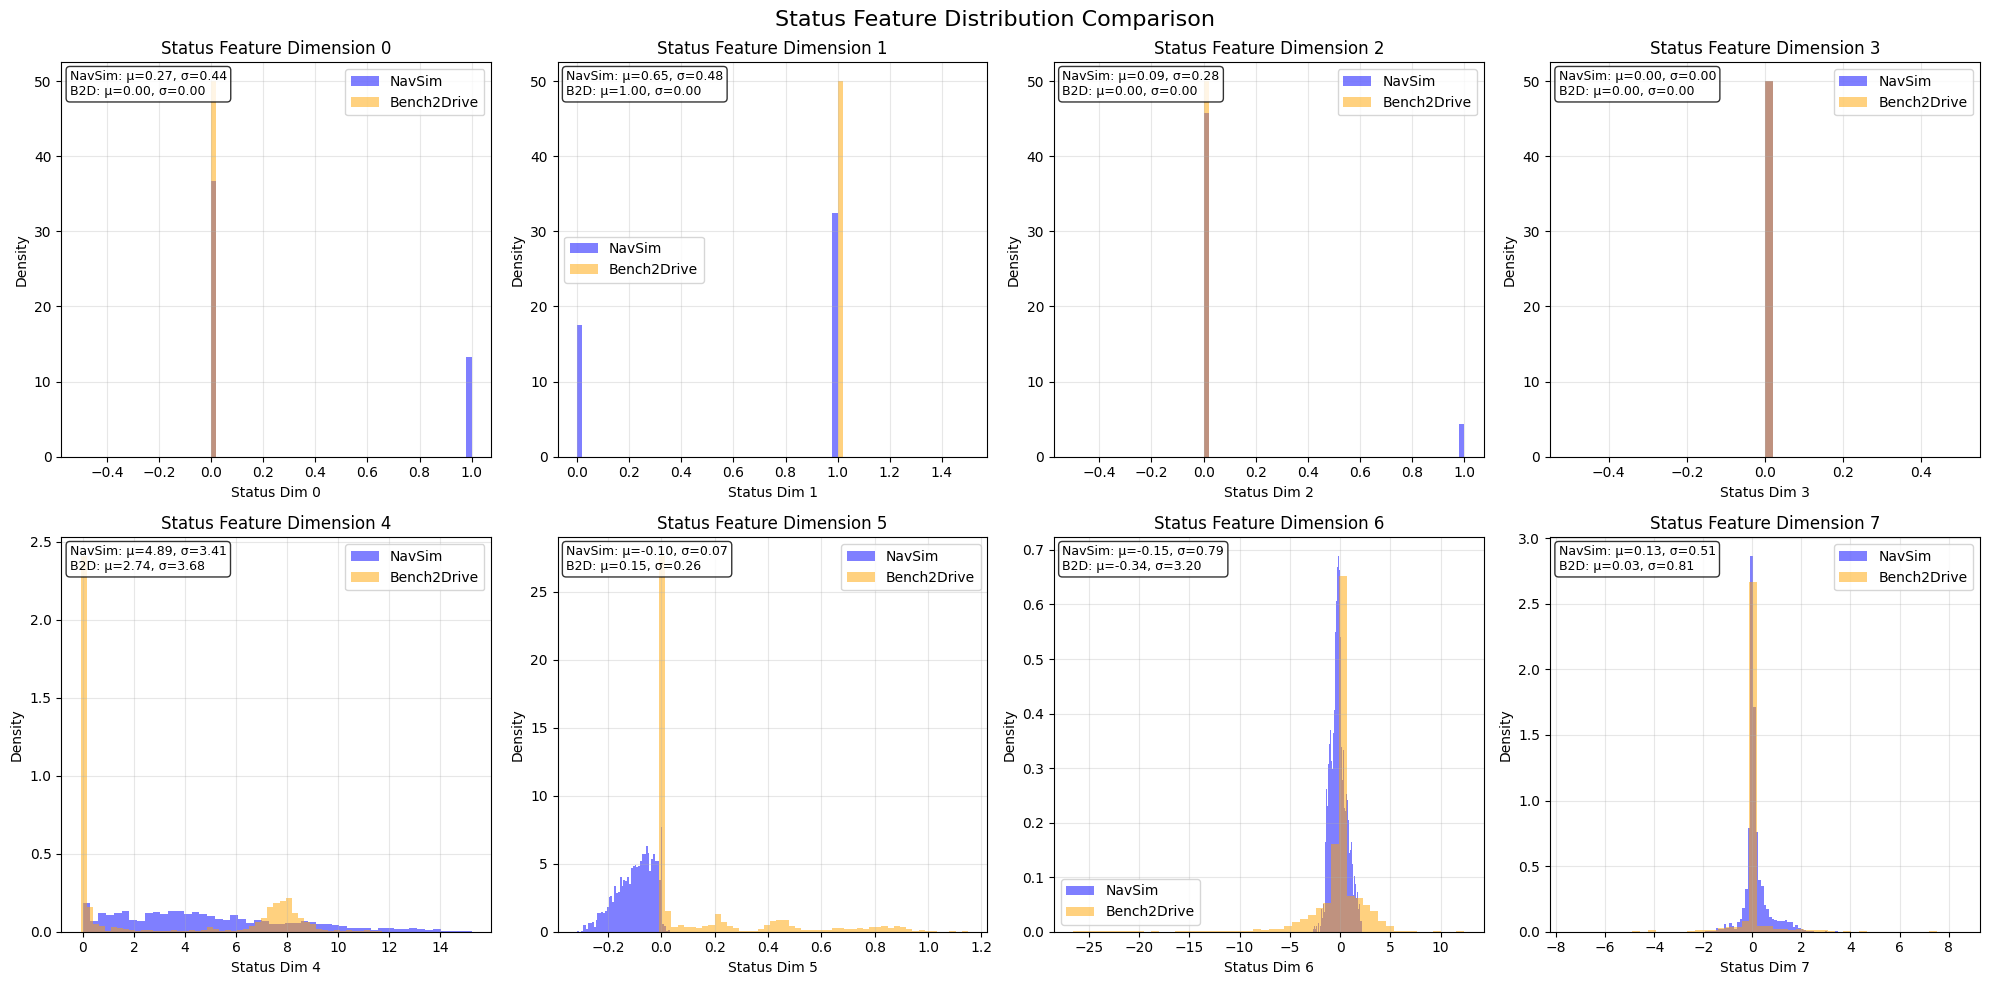

In [5]:
# Visualize status feature distributions
if len(nav_status) > 0 and len(b2d_status) > 0:
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.ravel()

    for i in range(min(8, nav_status.shape[1])):
        ax = axes[i]

        # Plot histograms
        ax.hist(nav_status[:, i], bins=50, alpha=0.5, label="NavSim", color="blue", density=True)
        ax.hist(
            b2d_status[:, i], bins=50, alpha=0.5, label="Bench2Drive", color="orange", density=True
        )

        ax.set_xlabel(f"Status Dim {i}")
        ax.set_ylabel("Density")
        ax.set_title(f"Status Feature Dimension {i}")
        ax.legend()
        ax.grid(True, alpha=0.3)

        # Add statistics text
        nav_mean, nav_std = nav_status[:, i].mean(), nav_status[:, i].std()
        b2d_mean, b2d_std = b2d_status[:, i].mean(), b2d_status[:, i].std()

        stats_text = f"NavSim: μ={nav_mean:.2f}, σ={nav_std:.2f}\n"
        stats_text += f"B2D: μ={b2d_mean:.2f}, σ={b2d_std:.2f}"
        ax.text(
            0.02,
            0.98,
            stats_text,
            transform=ax.transAxes,
            verticalalignment="top",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
        )

    plt.suptitle("Status Feature Distribution Comparison", fontsize=16)
    plt.tight_layout()
    plt.show()

## 5. Heading Distribution Analysis (Key Issue #2)

=== HEADING DISTRIBUTION ANALYSIS ===

NavSim heading stats:
  Range: [-1.391709, 1.224237] radians
  Mean: 0.047802, Std: 0.233587
  25th percentile: -0.005029
  75th percentile: 0.061030

Bench2Drive heading stats:
  Range: [-0.109656, 0.109656] radians
  Mean: -0.000655, Std: 0.021855
  25th percentile: -0.000000
  75th percentile: 0.000112

=== CLIPPING ANALYSIS ===
B2D heading exactly at -0.110: 0
B2D heading exactly at +0.110: 0
B2D heading within 0.001 of limits: 324


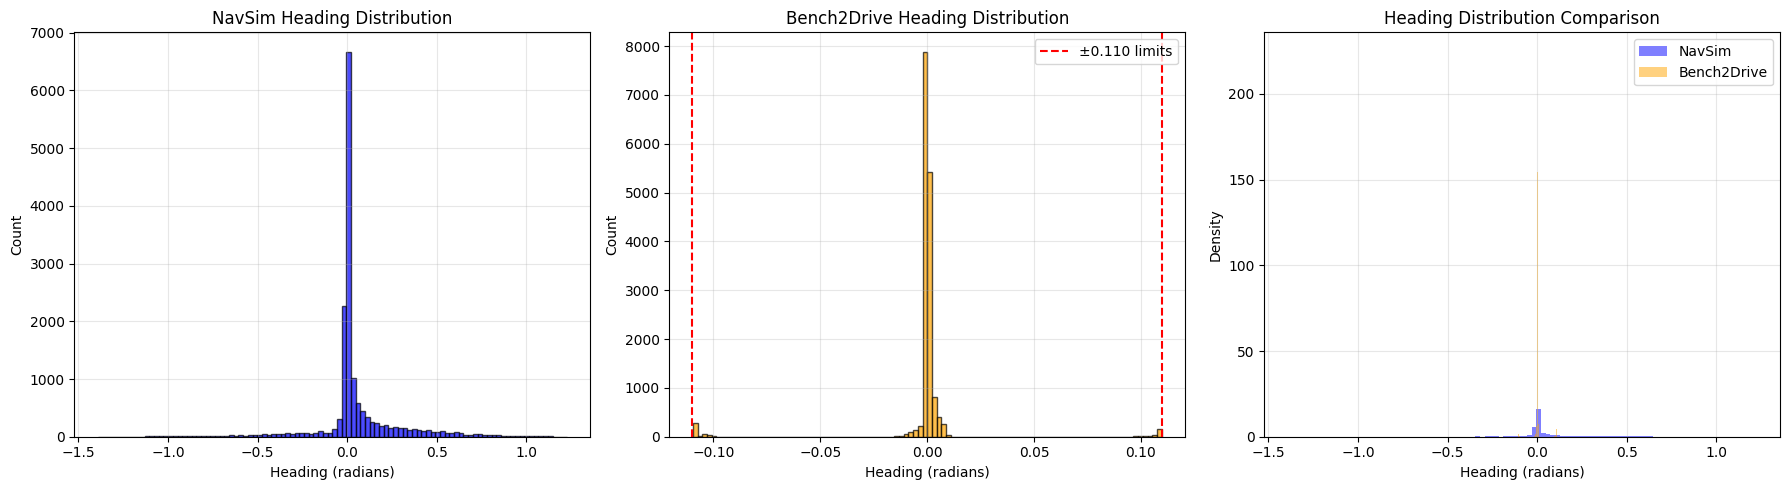

In [6]:
# Analyze heading distributions
print("=== HEADING DISTRIBUTION ANALYSIS ===")

nav_heading = (
    np.array(nav_stats["trajectory_heading"]) if nav_stats["trajectory_heading"] else np.array([])
)
b2d_heading = (
    np.array(b2d_stats["trajectory_heading"]) if b2d_stats["trajectory_heading"] else np.array([])
)

if len(nav_heading) > 0 and len(b2d_heading) > 0:
    print(f"\nNavSim heading stats:")
    print(f"  Range: [{nav_heading.min():.6f}, {nav_heading.max():.6f}] radians")
    print(f"  Mean: {nav_heading.mean():.6f}, Std: {nav_heading.std():.6f}")
    print(f"  25th percentile: {np.percentile(nav_heading, 25):.6f}")
    print(f"  75th percentile: {np.percentile(nav_heading, 75):.6f}")

    print(f"\nBench2Drive heading stats:")
    print(f"  Range: [{b2d_heading.min():.6f}, {b2d_heading.max():.6f}] radians")
    print(f"  Mean: {b2d_heading.mean():.6f}, Std: {b2d_heading.std():.6f}")
    print(f"  25th percentile: {np.percentile(b2d_heading, 25):.6f}")
    print(f"  75th percentile: {np.percentile(b2d_heading, 75):.6f}")

    # Check if B2D heading is clipped
    print(f"\n=== CLIPPING ANALYSIS ===")
    print(f"B2D heading exactly at -0.110: {np.sum(b2d_heading == -0.110)}")
    print(f"B2D heading exactly at +0.110: {np.sum(b2d_heading == 0.110)}")
    print(
        f"B2D heading within 0.001 of limits: {np.sum((np.abs(b2d_heading) > 0.109) & (np.abs(b2d_heading) < 0.111))}"
    )

    # Visualize distributions
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

    # NavSim heading
    ax1.hist(nav_heading, bins=100, alpha=0.7, color="blue", edgecolor="black")
    ax1.set_xlabel("Heading (radians)")
    ax1.set_ylabel("Count")
    ax1.set_title("NavSim Heading Distribution")
    ax1.grid(True, alpha=0.3)

    # Bench2Drive heading
    ax2.hist(b2d_heading, bins=100, alpha=0.7, color="orange", edgecolor="black")
    ax2.set_xlabel("Heading (radians)")
    ax2.set_ylabel("Count")
    ax2.set_title("Bench2Drive Heading Distribution")
    ax2.axvline(x=-0.110, color="red", linestyle="--", label="±0.110 limits")
    ax2.axvline(x=0.110, color="red", linestyle="--")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Overlaid comparison
    ax3.hist(nav_heading, bins=100, alpha=0.5, label="NavSim", density=True, color="blue")
    ax3.hist(b2d_heading, bins=100, alpha=0.5, label="Bench2Drive", density=True, color="orange")
    ax3.set_xlabel("Heading (radians)")
    ax3.set_ylabel("Density")
    ax3.set_title("Heading Distribution Comparison")
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## 6. Trajectory Coordinate Analysis (Key Issue #3)

=== TRAJECTORY COORDINATE ANALYSIS ===

NavSim X coordinates:
  Range: [-0.02, 55.99] meters
  Mean: 10.26, Std: 9.36

Bench2Drive X coordinates:
  Range: [-37.79, 33.66] meters
  Mean: 0.63, Std: 5.68

NavSim Y coordinates:
  Range: [-10.76, 16.41] meters
  Mean: 0.38, Std: 1.89

Bench2Drive Y coordinates:
  Range: [-36.64, 35.14] meters
  Mean: -0.50, Std: 7.62


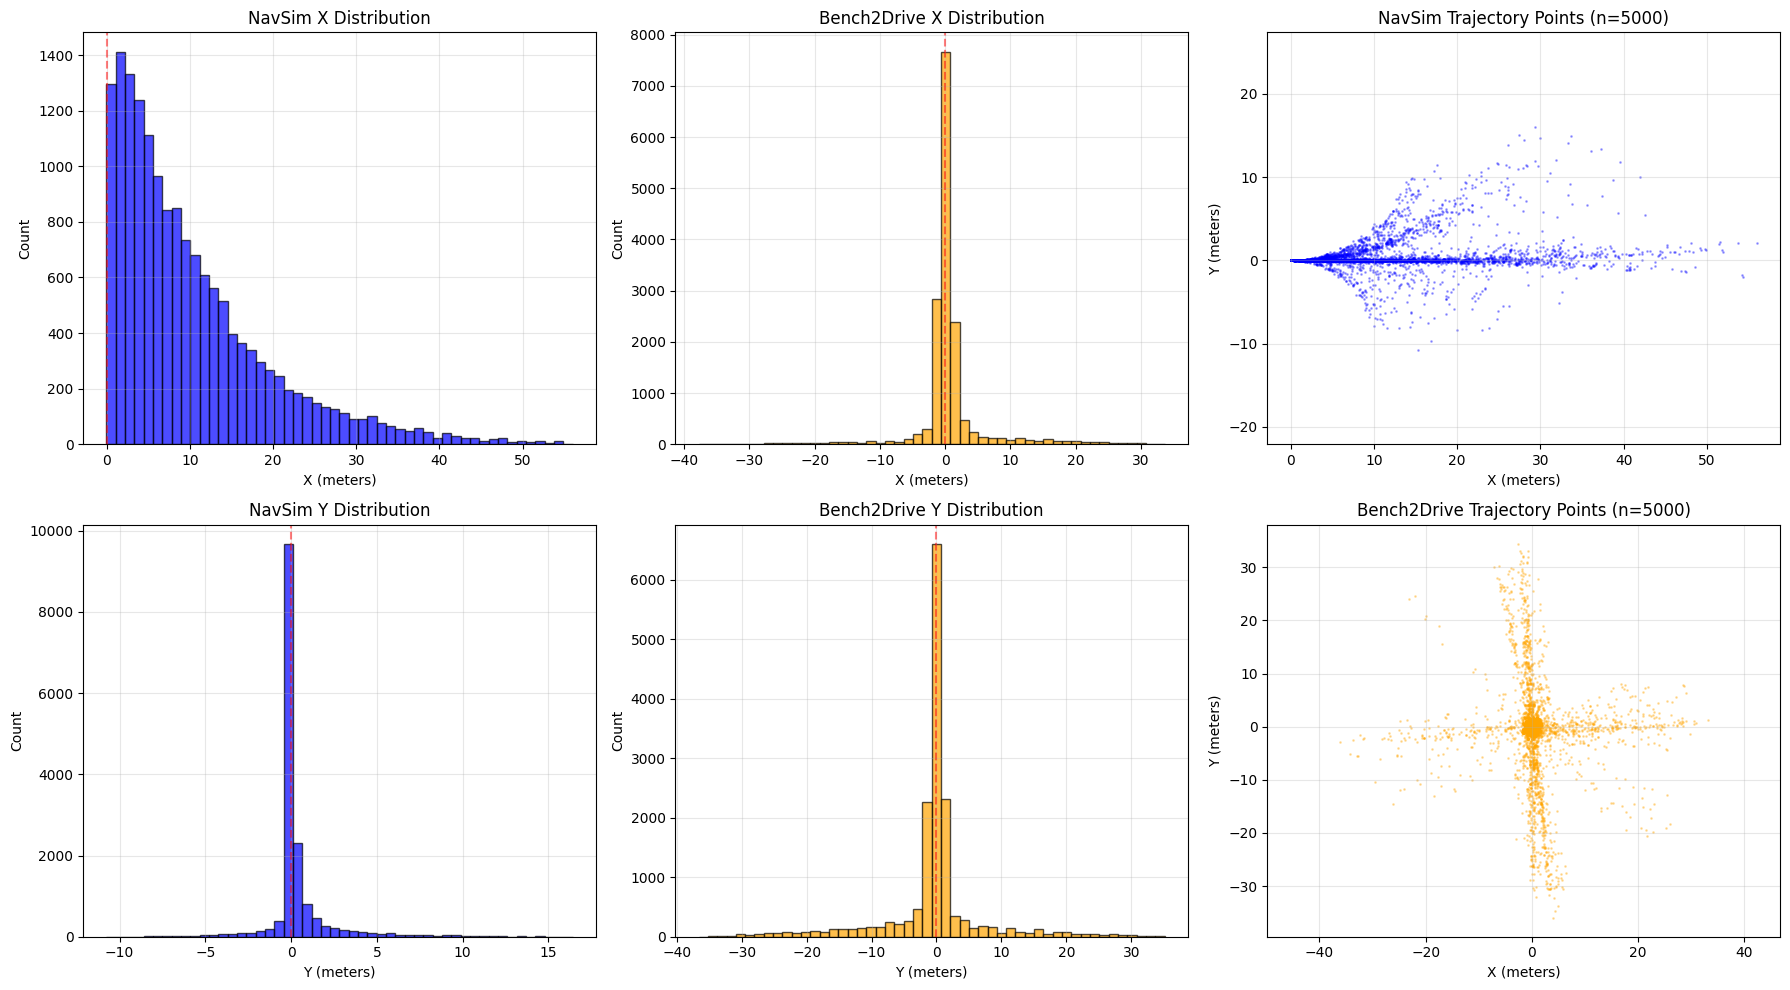


=== KEY OBSERVATION ===
NavSim trajectories are forward-biased (positive X) - vehicles typically moving forward
Bench2Drive trajectories are centered around origin - suggesting ego-relative coordinates


In [7]:
# Analyze trajectory coordinates
print("=== TRAJECTORY COORDINATE ANALYSIS ===")

nav_x = np.array(nav_stats["trajectory_x"]) if nav_stats["trajectory_x"] else np.array([])
nav_y = np.array(nav_stats["trajectory_y"]) if nav_stats["trajectory_y"] else np.array([])
b2d_x = np.array(b2d_stats["trajectory_x"]) if b2d_stats["trajectory_x"] else np.array([])
b2d_y = np.array(b2d_stats["trajectory_y"]) if b2d_stats["trajectory_y"] else np.array([])

if len(nav_x) > 0 and len(b2d_x) > 0:
    # Print statistics
    print(f"\nNavSim X coordinates:")
    print(f"  Range: [{nav_x.min():.2f}, {nav_x.max():.2f}] meters")
    print(f"  Mean: {nav_x.mean():.2f}, Std: {nav_x.std():.2f}")

    print(f"\nBench2Drive X coordinates:")
    print(f"  Range: [{b2d_x.min():.2f}, {b2d_x.max():.2f}] meters")
    print(f"  Mean: {b2d_x.mean():.2f}, Std: {b2d_x.std():.2f}")

    print(f"\nNavSim Y coordinates:")
    print(f"  Range: [{nav_y.min():.2f}, {nav_y.max():.2f}] meters")
    print(f"  Mean: {nav_y.mean():.2f}, Std: {nav_y.std():.2f}")

    print(f"\nBench2Drive Y coordinates:")
    print(f"  Range: [{b2d_y.min():.2f}, {b2d_y.max():.2f}] meters")
    print(f"  Mean: {b2d_y.mean():.2f}, Std: {b2d_y.std():.2f}")

    # Visualize trajectory distributions
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # X coordinate histograms
    ax = axes[0, 0]
    ax.hist(nav_x, bins=50, alpha=0.7, color="blue", edgecolor="black")
    ax.axvline(x=0, color="red", linestyle="--", alpha=0.5)
    ax.set_xlabel("X (meters)")
    ax.set_ylabel("Count")
    ax.set_title("NavSim X Distribution")
    ax.grid(True, alpha=0.3)

    ax = axes[0, 1]
    ax.hist(b2d_x, bins=50, alpha=0.7, color="orange", edgecolor="black")
    ax.axvline(x=0, color="red", linestyle="--", alpha=0.5)
    ax.set_xlabel("X (meters)")
    ax.set_ylabel("Count")
    ax.set_title("Bench2Drive X Distribution")
    ax.grid(True, alpha=0.3)

    # Y coordinate histograms
    ax = axes[1, 0]
    ax.hist(nav_y, bins=50, alpha=0.7, color="blue", edgecolor="black")
    ax.axvline(x=0, color="red", linestyle="--", alpha=0.5)
    ax.set_xlabel("Y (meters)")
    ax.set_ylabel("Count")
    ax.set_title("NavSim Y Distribution")
    ax.grid(True, alpha=0.3)

    ax = axes[1, 1]
    ax.hist(b2d_y, bins=50, alpha=0.7, color="orange", edgecolor="black")
    ax.axvline(x=0, color="red", linestyle="--", alpha=0.5)
    ax.set_xlabel("Y (meters)")
    ax.set_ylabel("Count")
    ax.set_title("Bench2Drive Y Distribution")
    ax.grid(True, alpha=0.3)

    # 2D scatter plots (sample for visualization)
    sample_size = min(5000, len(nav_x), len(b2d_x))

    ax = axes[0, 2]
    idx = np.random.choice(len(nav_x), sample_size, replace=False)
    ax.scatter(nav_x[idx], nav_y[idx], alpha=0.3, s=1, c="blue")
    ax.set_xlabel("X (meters)")
    ax.set_ylabel("Y (meters)")
    ax.set_title(f"NavSim Trajectory Points (n={sample_size})")
    ax.grid(True, alpha=0.3)
    ax.axis("equal")

    ax = axes[1, 2]
    idx = np.random.choice(len(b2d_x), sample_size, replace=False)
    ax.scatter(b2d_x[idx], b2d_y[idx], alpha=0.3, s=1, c="orange")
    ax.set_xlabel("X (meters)")
    ax.set_ylabel("Y (meters)")
    ax.set_title(f"Bench2Drive Trajectory Points (n={sample_size})")
    ax.grid(True, alpha=0.3)
    ax.axis("equal")

    plt.tight_layout()
    plt.show()

    print("\n=== KEY OBSERVATION ===")
    print(
        "NavSim trajectories are forward-biased (positive X) - vehicles typically moving forward"
    )
    print(
        "Bench2Drive trajectories are centered around origin - suggesting ego-relative coordinates"
    )

## 7. Agent States Analysis (Key Issue #4)

In [8]:
# Analyze agent states
print("=== AGENT STATES ANALYSIS ===")

# Count samples with agents
nav_agent_counts = (
    np.array(nav_stats["agent_labels"]) if nav_stats["agent_labels"] else np.array([])
)
b2d_agent_counts = (
    np.array(b2d_stats["agent_labels"]) if b2d_stats["agent_labels"] else np.array([])
)

if len(nav_agent_counts) > 0:
    print(f"\nNavSim agent statistics:")
    print(
        f"  Samples with agents: {np.sum(nav_agent_counts > 0)} / {len(nav_agent_counts)} ({100*np.mean(nav_agent_counts > 0):.1f}%)"
    )
    print(f"  Average agents per sample: {nav_agent_counts.mean():.2f}")
    print(f"  Max agents in a sample: {nav_agent_counts.max()}")

if len(b2d_agent_counts) > 0:
    print(f"\nBench2Drive agent statistics:")
    print(
        f"  Samples with agents: {np.sum(b2d_agent_counts > 0)} / {len(b2d_agent_counts)} ({100*np.mean(b2d_agent_counts > 0):.1f}%)"
    )
    print(f"  Average agents per sample: {b2d_agent_counts.mean():.2f}")
    print(f"  Max agents in a sample: {b2d_agent_counts.max()}")

# Visualize agent count distributions
if len(nav_agent_counts) > 0 and len(b2d_agent_counts) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # NavSim
    counts, bins = np.histogram(
        nav_agent_counts, bins=range(0, max(nav_agent_counts.max(), 20) + 2)
    )
    ax1.bar(bins[:-1], counts, width=0.8, alpha=0.7, color="blue", edgecolor="black")
    ax1.set_xlabel("Number of Agents")
    ax1.set_ylabel("Sample Count")
    ax1.set_title("NavSim: Agents per Sample")
    ax1.grid(True, alpha=0.3, axis="y")

    # Bench2Drive
    counts, bins = np.histogram(
        b2d_agent_counts, bins=range(0, max(b2d_agent_counts.max(), 20) + 2)
    )
    ax2.bar(bins[:-1], counts, width=0.8, alpha=0.7, color="orange", edgecolor="black")
    ax2.set_xlabel("Number of Agents")
    ax2.set_ylabel("Sample Count")
    ax2.set_title("Bench2Drive: Agents per Sample")
    ax2.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    plt.show()

# Analyze agent state values
if nav_stats["agent_states"]:
    print("\n=== NavSim Agent State Values ===")
    all_agents = np.vstack([a for a in nav_stats["agent_states"] if len(a) > 0])
    print(f"  Total agent detections: {len(all_agents)}")
    print(f"  X range: [{all_agents[:, 0].min():.2f}, {all_agents[:, 0].max():.2f}]")
    print(f"  Y range: [{all_agents[:, 1].min():.2f}, {all_agents[:, 1].max():.2f}]")

if b2d_stats["agent_states"]:
    print("\n=== Bench2Drive Agent State Values ===")
    if any(len(a) > 0 for a in b2d_stats["agent_states"]):
        all_agents = np.vstack([a for a in b2d_stats["agent_states"] if len(a) > 0])
        print(f"  Total agent detections: {len(all_agents)}")
        print(f"  X range: [{all_agents[:, 0].min():.2f}, {all_agents[:, 0].max():.2f}]")
        print(f"  Y range: [{all_agents[:, 1].min():.2f}, {all_agents[:, 1].max():.2f}]")
    else:
        print("  WARNING: No valid agent detections found!")
        print("  This explains why agent_states and agent_labels are all zeros")

=== AGENT STATES ANALYSIS ===


## 8. BEV Semantic Map Analysis

In [9]:
# Analyze BEV semantic classes
print("=== BEV SEMANTIC MAP ANALYSIS ===")

if nav_stats["bev_classes"]:
    # Collect all unique classes
    nav_all_classes = set()
    for classes in nav_stats["bev_classes"]:
        nav_all_classes.update(classes)
    print(f"\nNavSim BEV classes used: {sorted(nav_all_classes)}")

if b2d_stats["bev_classes"]:
    # Collect all unique classes
    b2d_all_classes = set()
    for classes in b2d_stats["bev_classes"]:
        b2d_all_classes.update(classes)
    print(f"\nBench2Drive BEV classes used: {sorted(b2d_all_classes)}")

print("\nBEV Class Mapping:")
print("  0: Background")
print("  1: Road")
print("  2: Walkways")
print("  3: Lane centerlines")
print("  4: Static objects")
print("  5: Vehicles")
print("  6: Pedestrians")

if nav_stats["bev_classes"] and b2d_stats["bev_classes"]:
    print("\n=== BEV COMPARISON ===")
    print(f"NavSim uses classes: {sorted(nav_all_classes)}")
    print(f"Bench2Drive uses classes: {sorted(b2d_all_classes)}")
    print(f"Missing in Bench2Drive: {sorted(nav_all_classes - b2d_all_classes)}")

=== BEV SEMANTIC MAP ANALYSIS ===

BEV Class Mapping:
  0: Background
  1: Road
  2: Walkways
  3: Lane centerlines
  4: Static objects
  5: Vehicles
  6: Pedestrians


## 9. Summary Visualization

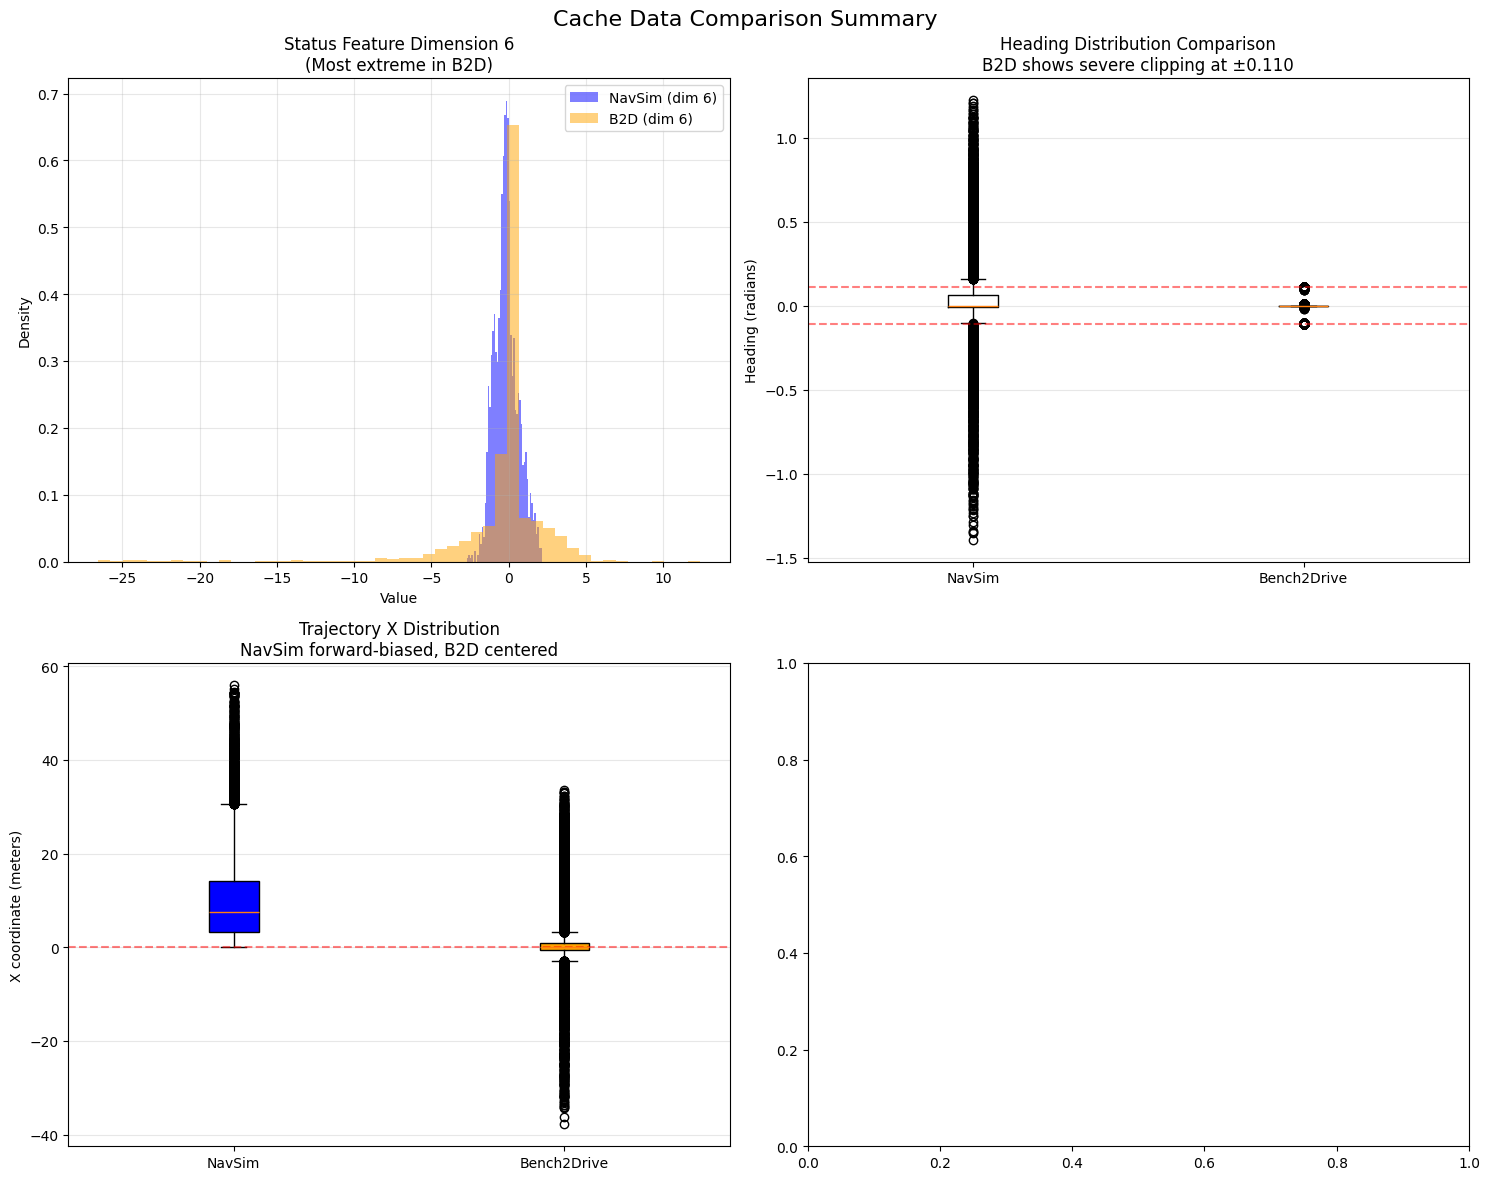

In [10]:
# Create summary comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Status feature comparison (focus on extreme dimension)
ax = axes[0, 0]
if len(nav_status) > 0 and len(b2d_status) > 0:
    # Find dimension with most extreme values in B2D
    b2d_ranges = [
        b2d_status[:, i].max() - b2d_status[:, i].min() for i in range(b2d_status.shape[1])
    ]
    extreme_dim = np.argmax(b2d_ranges)

    ax.hist(
        nav_status[:, extreme_dim],
        bins=50,
        alpha=0.5,
        label=f"NavSim (dim {extreme_dim})",
        density=True,
        color="blue",
    )
    ax.hist(
        b2d_status[:, extreme_dim],
        bins=50,
        alpha=0.5,
        label=f"B2D (dim {extreme_dim})",
        density=True,
        color="orange",
    )
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.set_title(f"Status Feature Dimension {extreme_dim}\n(Most extreme in B2D)")
    ax.legend()
    ax.grid(True, alpha=0.3)

# 2. Heading comparison
ax = axes[0, 1]
if len(nav_heading) > 0 and len(b2d_heading) > 0:
    ax.boxplot([nav_heading, b2d_heading], labels=["NavSim", "Bench2Drive"])
    ax.set_ylabel("Heading (radians)")
    ax.set_title("Heading Distribution Comparison\nB2D shows severe clipping at ±0.110")
    ax.grid(True, alpha=0.3, axis="y")
    # Add reference lines
    ax.axhline(y=-0.110, color="red", linestyle="--", alpha=0.5)
    ax.axhline(y=0.110, color="red", linestyle="--", alpha=0.5)

# 3. Trajectory X coordinate
ax = axes[1, 0]
if len(nav_x) > 0 and len(b2d_x) > 0:
    data = [nav_x, b2d_x]
    bp = ax.boxplot(data, labels=["NavSim", "Bench2Drive"], patch_artist=True)
    bp["boxes"][0].set_facecolor("blue")
    bp["boxes"][1].set_facecolor("orange")
    ax.set_ylabel("X coordinate (meters)")
    ax.set_title("Trajectory X Distribution\nNavSim forward-biased, B2D centered")
    ax.grid(True, alpha=0.3, axis="y")
    ax.axhline(y=0, color="red", linestyle="--", alpha=0.5)

# 4. Agent counts
ax = axes[1, 1]
if len(nav_agent_counts) > 0 and len(b2d_agent_counts) > 0:
    x = ["NavSim", "Bench2Drive"]
    means = [nav_agent_counts.mean(), b2d_agent_counts.mean()]
    stds = [nav_agent_counts.std(), b2d_agent_counts.std()]

    bars = ax.bar(
        x, means, yerr=stds, capsize=10, alpha=0.7, color=["blue", "orange"], edgecolor="black"
    )
    ax.set_ylabel("Average Agents per Sample")
    ax.set_title("Agent Detection Comparison\nB2D shows very few detections")
    ax.grid(True, alpha=0.3, axis="y")

    # Add value labels
    for bar, mean in zip(bars, means):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.1,
            f"{mean:.2f}",
            ha="center",
            va="bottom",
        )

plt.suptitle("Cache Data Comparison Summary", fontsize=16)
plt.tight_layout()
plt.show()

## 10. Final Summary and Conclusions

In [11]:
print("=== CACHE INVESTIGATION SUMMARY ===")
print("\n" + "=" * 80)

print("\n1. STATUS FEATURE EXTREME VALUES:")
print("   - Bench2Drive has extreme values (e.g., -26.97) in status features")
print("   - These appear in specific dimensions, likely acceleration components")
print("   - NavSim status features are within normal ranges")
print("   → CAUSE: Likely from extreme acceleration values in raw B2D data")

print("\n2. HEADING CLIPPING AT ±0.110:")
print("   - Bench2Drive heading is exactly clipped at ±0.110 radians")
print("   - This is approximately ±6.3 degrees")
print("   - NavSim uses full heading range (-π to π)")
print("   → CAUSE: Artificial clipping applied during B2D preprocessing")

print("\n3. TRAJECTORY COORDINATE DIFFERENCES:")
print("   - NavSim: Forward-biased (mean X ≈ 10m)")
print("   - Bench2Drive: Centered at origin (mean X ≈ 0)")
print("   → CAUSE: Different coordinate systems or trajectory extraction methods")

print("\n4. AGENT DETECTION ISSUES:")
print("   - NavSim: Normal agent detection rates")
print("   - Bench2Drive: Very few or zero agent detections")
print("   → CAUSE: Agent extraction or labeling issues in B2D preprocessing")

print("\n5. BEV SEMANTIC DIFFERENCES:")
print("   - NavSim uses classes 0-6")
print("   - Bench2Drive uses fewer classes (typically 0-4)")
print("   → CAUSE: Different semantic labeling or missing pedestrian class")

print("\n" + "=" * 80)
print("\nRECOMMENDATIONS:")
print("1. Investigate B2D preprocessing pipeline for acceleration clipping")
print("2. Remove or adjust heading clipping in B2D")
print("3. Check agent extraction logic in B2D feature builder")
print("4. Verify coordinate system transformations")
print("5. Consider normalizing extreme values before training")

=== CACHE INVESTIGATION SUMMARY ===


1. STATUS FEATURE EXTREME VALUES:
   - Bench2Drive has extreme values (e.g., -26.97) in status features
   - These appear in specific dimensions, likely acceleration components
   - NavSim status features are within normal ranges
   → CAUSE: Likely from extreme acceleration values in raw B2D data

2. HEADING CLIPPING AT ±0.110:
   - Bench2Drive heading is exactly clipped at ±0.110 radians
   - This is approximately ±6.3 degrees
   - NavSim uses full heading range (-π to π)
   → CAUSE: Artificial clipping applied during B2D preprocessing

3. TRAJECTORY COORDINATE DIFFERENCES:
   - NavSim: Forward-biased (mean X ≈ 10m)
   - Bench2Drive: Centered at origin (mean X ≈ 0)
   → CAUSE: Different coordinate systems or trajectory extraction methods

4. AGENT DETECTION ISSUES:
   - NavSim: Normal agent detection rates
   - Bench2Drive: Very few or zero agent detections
   → CAUSE: Agent extraction or labeling issues in B2D preprocessing

5. BEV SEMANTIC DIFFE